# 5. Model Comparison

Logistic Regression vs. Random Forest, across feature-availability scenarios, per-class recall, and stratified 5-fold cross-validation.

Loads the results tables saved by notebooks 3 and 4; refits both models once more on Full Data (same split, via `evaluate_feature_set`) to get a matched pair of predictions for the per-class recall comparison in 5.2.

In [2]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate

from src.evaluate import evaluate_feature_set
from src.models import get_logistic_regression, get_random_forest
from src.preprocessing import build_model_pipeline, get_feature_availability_sets, load_data, TARGET_COL

sns.set_theme(style="whitegrid")
df = load_data()
feature_sets = get_feature_availability_sets(df)

feature_results_df = pd.read_csv("../data/processed/logreg_feature_availability.csv")
rf_feature_results_df = pd.read_csv("../data/processed/rf_feature_availability.csv")


## 5.1 Logistic Regression vs. Random Forest across feature availability

In [3]:
logreg_compare = feature_results_df.copy()
logreg_compare["Model"] = "Logistic Regression"

rf_compare = rf_feature_results_df.copy()
rf_compare["Model"] = "Random Forest"

all_model_results = pd.concat([logreg_compare, rf_compare], ignore_index=True)
display(all_model_results.round(3))


,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Model
0,Day 1,0.573,0.550,0.577,0.522,0.588,Logistic Regression
1,After Semester 1,0.698,0.658,0.683,0.560,0.758,Logistic Regression
2,Full Data,0.725,0.689,0.680,0.635,0.787,Logistic Regression
3,Day 1,0.612,0.539,0.627,0.258,0.731,Random Forest
4,After Semester 1,0.716,0.647,0.697,0.390,0.846,Random Forest
5,Full Data,0.763,0.713,0.718,0.547,0.869,Random Forest


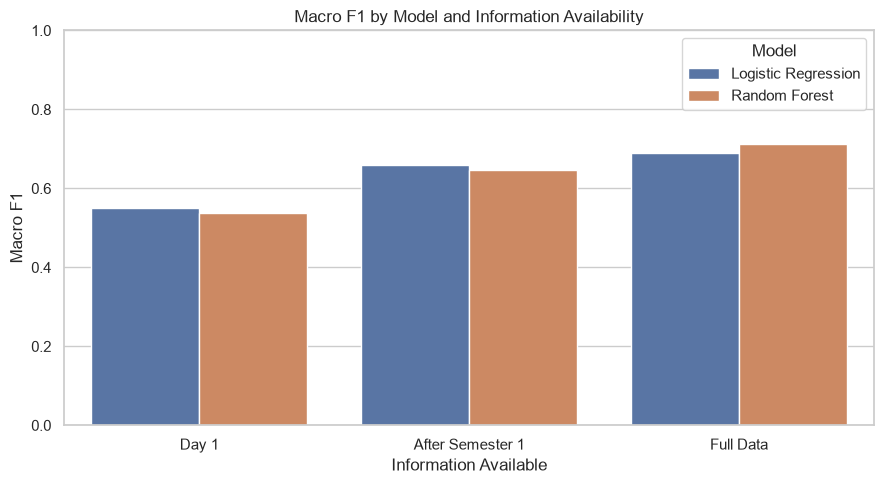

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=all_model_results, x="Feature Set", y="Macro F1", hue="Model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Macro F1 by Model and Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Macro F1")
plt.tight_layout()
plt.show()


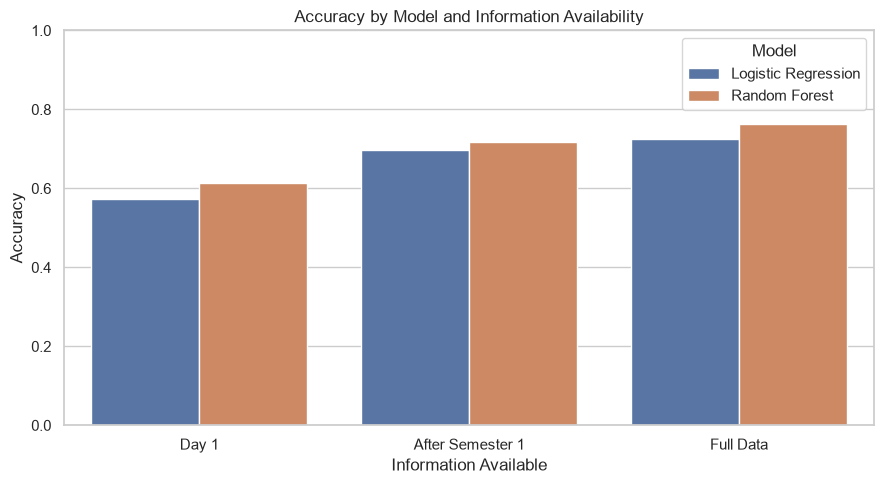

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=all_model_results, x="Feature Set", y="Accuracy", hue="Model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Accuracy by Model and Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


## 5.2 Per-class recall

Refits both models once on Full Data (same 80/20 split, since `evaluate_feature_set` uses the same `random_state`) to get a matched prediction pair for a direct per-class recall comparison.

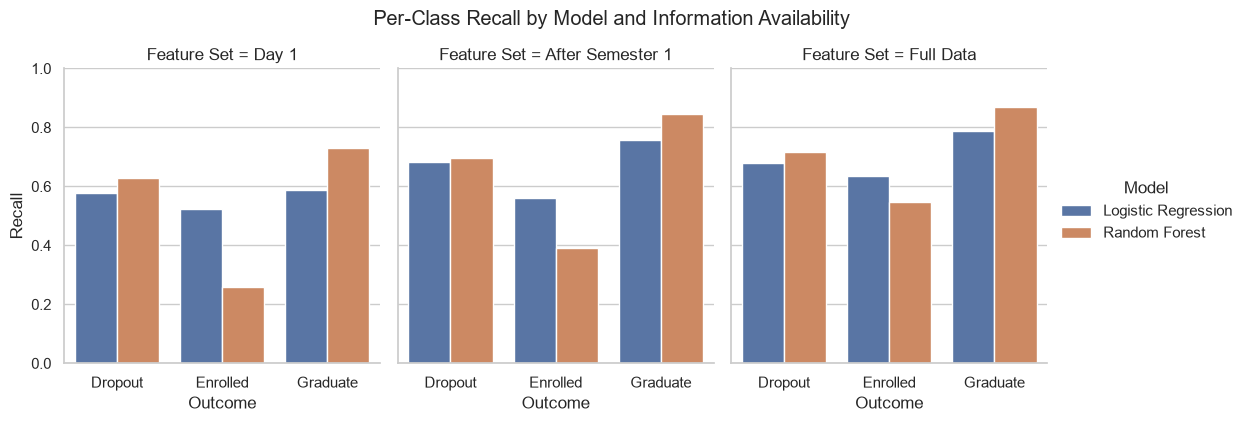

In [6]:
recall_long = all_model_results.melt(
    id_vars=["Feature Set", "Model"],
    value_vars=["Dropout Recall", "Enrolled Recall", "Graduate Recall"],
    var_name="Outcome", value_name="Recall"
)
recall_long["Outcome"] = recall_long["Outcome"].str.replace(" Recall", "", regex=False)

g = sns.catplot(
    data=recall_long, x="Outcome", y="Recall", hue="Model", col="Feature Set",
    kind="bar", height=4, aspect=0.9
)
g.set(ylim=(0, 1))
g.set_axis_labels("Outcome", "Recall")
g.fig.suptitle("Per-Class Recall by Model and Information Availability", y=1.05)
plt.show()


In [7]:
classes = ["Dropout", "Enrolled", "Graduate"]

_, _, X_test_lr, y_test_lr, y_pred_lr = evaluate_feature_set(
    df, feature_sets["Full Data"], "Full Data", get_logistic_regression(),
    scale_numeric=True, return_split=True
)
_, _, X_test_rf, y_test_rf, y_pred_rf = evaluate_feature_set(
    df, feature_sets["Full Data"], "Full Data", get_random_forest(),
    scale_numeric=False, return_split=True
)

logreg_class_recall = recall_score(y_test_lr, y_pred_lr, labels=classes, average=None)
rf_class_recall = recall_score(y_test_rf, y_pred_rf, labels=classes, average=None)

recall_comparison = pd.DataFrame({
    "Class": classes,
    "Logistic Regression": logreg_class_recall,
    "Random Forest": rf_class_recall
})
display(recall_comparison.round(3))


,Class,Logistic Regression,Random Forest
0,Dropout,0.680,0.718
1,Enrolled,0.635,0.547
2,Graduate,0.787,0.869


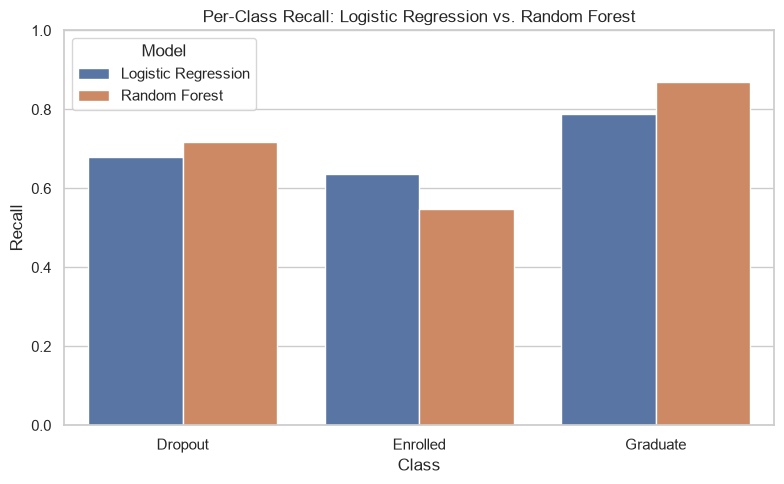

In [8]:
recall_comparison_long = recall_comparison.melt(id_vars="Class", var_name="Model", value_name="Recall")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=recall_comparison_long, x="Class", y="Recall", hue="Model", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Per-Class Recall: Logistic Regression vs. Random Forest")
plt.tight_layout()
plt.show()


## 5.3 Stratified 5-fold cross-validation

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "macro_f1": "f1_macro", "macro_recall": "recall_macro"}

full_cols = feature_sets["Full Data"]
X_cv = df[full_cols]
y_cv = df[TARGET_COL]

logreg_cv_pipe = build_model_pipeline(get_logistic_regression(random_state=42), full_cols, scale_numeric=True)
logreg_cv_results = cross_validate(logreg_cv_pipe, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)

rf_cv_pipe = build_model_pipeline(get_random_forest(random_state=42), full_cols, scale_numeric=False)
rf_cv_results = cross_validate(rf_cv_pipe, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)

cv_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean Accuracy": [logreg_cv_results["test_accuracy"].mean(), rf_cv_results["test_accuracy"].mean()],
    "SD Accuracy": [logreg_cv_results["test_accuracy"].std(), rf_cv_results["test_accuracy"].std()],
    "Mean Macro F1": [logreg_cv_results["test_macro_f1"].mean(), rf_cv_results["test_macro_f1"].mean()],
    "SD Macro F1": [logreg_cv_results["test_macro_f1"].std(), rf_cv_results["test_macro_f1"].std()],
    "Mean Macro Recall": [logreg_cv_results["test_macro_recall"].mean(), rf_cv_results["test_macro_recall"].mean()],
    "SD Macro Recall": [logreg_cv_results["test_macro_recall"].std(), rf_cv_results["test_macro_recall"].std()],
})
display(cv_comparison.round(3))


,Model,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall
0,Logistic Regression,0.748,0.016,0.708,0.015,0.716,0.014
1,Random Forest,0.773,0.011,0.716,0.012,0.709,0.012


In [10]:
for _, row in cv_comparison.iterrows():
    print(row["Model"])
    print(f"  Accuracy: {row['Mean Accuracy']:.3f} +/- {row['SD Accuracy']:.3f}")
    print(f"  Macro F1: {row['Mean Macro F1']:.3f} +/- {row['SD Macro F1']:.3f}")
    print(f"  Macro Recall: {row['Mean Macro Recall']:.3f} +/- {row['SD Macro Recall']:.3f}")
    print()


Logistic Regression
  Accuracy: 0.748 +/- 0.016
  Macro F1: 0.708 +/- 0.015
  Macro Recall: 0.716 +/- 0.014

Random Forest
  Accuracy: 0.773 +/- 0.011
  Macro F1: 0.716 +/- 0.012
  Macro Recall: 0.709 +/- 0.012

